1.0000000000000002
255


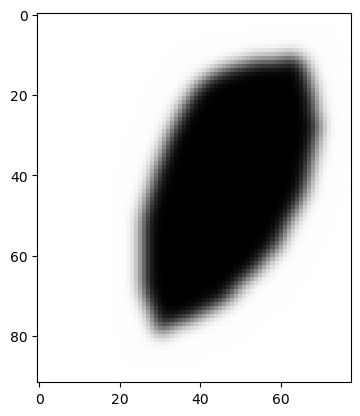

In [10]:
from skimage import io, filters, color
import matplotlib.pyplot as plt
import numpy as np
my_img = io.imread('test.png')
if my_img.shape[-1] == 4:
        my_img = my_img[..., :3]
my_img = color.rgb2gray(my_img)
blurred_image = filters.gaussian(my_img, sigma=2)
print(blurred_image.max())
if blurred_image.max() <= 2.0:
    blurred_image = (blurred_image * 255).astype(np.uint8)
print(blurred_image.max())
io.imsave('blurred_image.png', blurred_image)
plt.imshow(blurred_image, cmap='gray')
plt.show()

C:\Users\Vera\AppData\Local\Temp\ipykernel_18824\2137402934.py:28: RuntimeWarning: invalid value encountered in divide
  normals = np.stack([gy, gx], axis=-1) / magnitude[..., None]


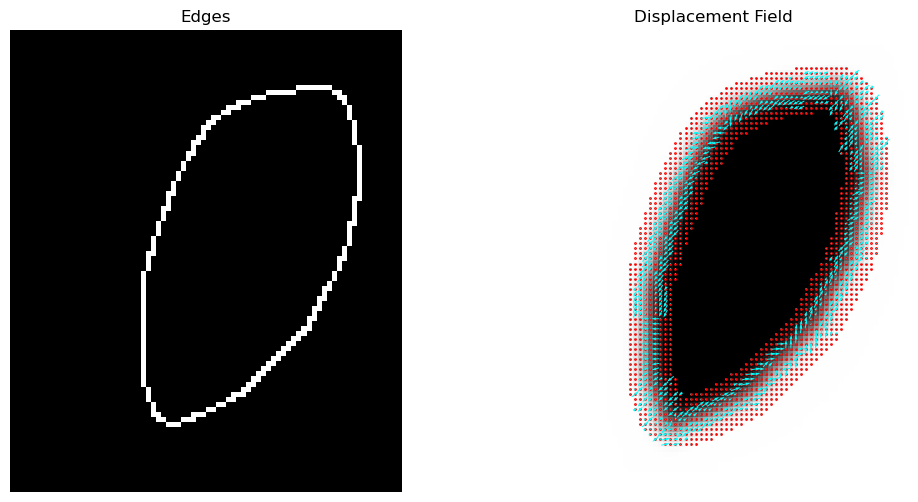

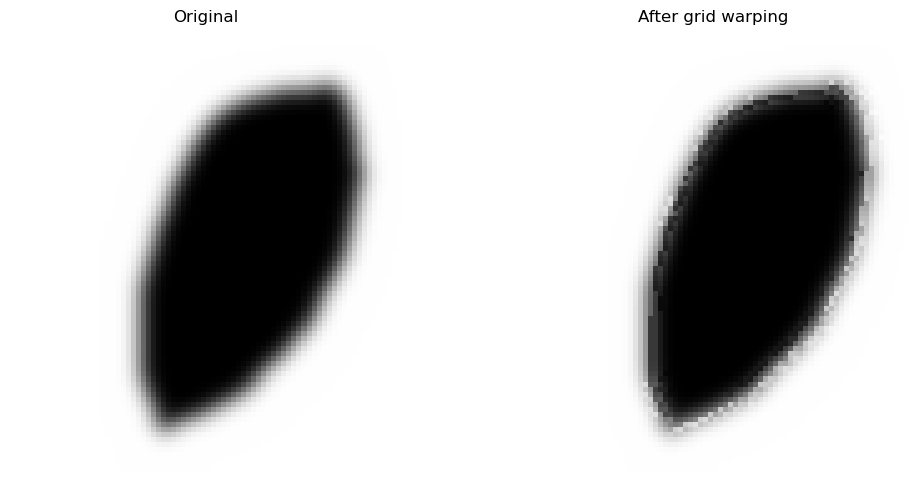

In [45]:
import numpy as np
from skimage import color, feature
from scipy.ndimage import sobel
from scipy.spatial import cKDTree

def displacement_function_1d(x, a):
    abs_x = np.abs(x)
    d = np.zeros_like(x)
    d[abs_x <= a] = -x[abs_x <= a]
    mask = (abs_x > a) & (abs_x <= 1.5 * a)
    d[mask] = - (3 * a - 2 * abs_x[mask]) * np.sign(x[mask])
    return d

def grid_warping(image, edge_radius=5, sigma=2.0, a=1.28):
    if image.shape[-1] == 4:
        image = image[..., :3]
    if image.shape[-1] != 2: # fix!!!
        # gray = color.rgb2gray(image)
        gray = image
    h, w = gray.shape

    edges = feature.canny(gray, sigma=sigma)
    edge_coords = np.column_stack(np.nonzero(edges))

    gy = sobel(gray, axis=0)
    gx = sobel(gray, axis=1)
    magnitude = np.hypot(gx, gy) + 1e-8
    normals = np.stack([gy, gx], axis=-1) / magnitude[..., None]
    
    yy, xx = np.meshgrid(np.arange(h), np.arange(w), indexing='ij')
    grid_coords = np.column_stack((yy.ravel(), xx.ravel()))

    tree = cKDTree(edge_coords)
    dists, idxs = tree.query(grid_coords, distance_upper_bound=edge_radius)
    mask = dists < edge_radius
    nearest_edges = edge_coords[np.clip(idxs, 0, len(edge_coords) - 1)]

    PQ = grid_coords[mask] - nearest_edges[mask] # направлен от пикселя эджа к пикселю
    edge_normals = normals[nearest_edges[mask, 0], nearest_edges[mask, 1]] # нормали в каждой точке эджа
    proj = np.sum(PQ * edge_normals, axis=1) # спроецируем на нормаль
    disp_1d = displacement_function_1d(proj, a) # вычислим насколько сдвигать
    full_displacement = edge_normals * disp_1d[:, None]

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(edges, cmap='gray')
    axes[0].set_title("Edges")
    axes[0].axis('off')

    # поле смещений
    axes[1].imshow(gray, cmap='gray')
    axes[1].scatter(grid_coords[mask][:, 1], grid_coords[mask][:, 0], s=1, c='red')
    axes[1].quiver(
        grid_coords[mask][:, 1], grid_coords[mask][:, 0],
        full_displacement[:, 1], full_displacement[:, 0],
        pivot='mid', units='width', scale=50, color='cyan'
    )
    axes[1].set_title("Displacement Field")
    axes[1].set_aspect(1)
    axes[1].axis('off')
    plt.show()

    # СДЕЛАТЬ ИНТЕРПОЛЯЦИЮ
    source_coords = grid_coords[mask]
    target_coords = np.round(source_coords + full_displacement).astype(int)
    target_coords[:, 0] = np.clip(target_coords[:, 0], 0, h - 1)
    target_coords[:, 1] = np.clip(target_coords[:, 1], 0, w - 1)
    warped_image = gray.copy()
    for src, tgt in zip(source_coords, target_coords):
        warped_image[tgt[0], tgt[1]] = gray[src[0], src[1]]

    return warped_image

if __name__ == "__main__":
    image = io.imread('blurred_image.png')
    result = grid_warping(image, edge_radius=5, sigma=2)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.imshow(image, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("After grid warping")
    plt.imshow(result, cmap='gray')
    plt.axis('off')
    plt.show()

    '''
    h, w = result.shape
    cy, cx = h // 2, w // 2
    r = 150  # half size of the patch

    patch_orig = image[cy - r:cy + r, cx - r:cx + r]
    patch_warp = result[cy - r:cy + r, cx - r:cx + r]

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.title("Original (Center Patch)")
    plt.imshow(patch_orig, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Warped (Center Patch)")
    plt.imshow(patch_warp, cmap='gray')
    plt.axis('off')

    plt.show()
    '''